Etapa 1: Setup do Ambiente

Importação das bibliotecas essenciais para manipulação de dados e integração com o banco de dados.

Pandas: Estruturação de dados em DataFrames.

SQLAlchemy: Engine de comunicação com bancos relacionai

In [3]:
import pandas as pd
import sqlalchemy

print(f"Pandas versão: {pd.__version__}")
print("Tudo pronto para conectar ao schema analytics!")

Pandas versão: 3.0.1
Tudo pronto para conectar ao schema analytics!


Etapa 2: Conexão com o Banco (PostgreSQL)
Configuração das credenciais de acesso ao servidor dw_ganalytics.

Engine: Criação do túnel de conexão via URL padronizada (usuário, senha, host e porta).

Validação: Verificação se o motor de conexão está ativo e pronto para receber consultas.

In [4]:
from sqlalchemy import create_engine

# Preencha com os seus dados do DBeaver:
USUARIO = 'postgres'
SENHA = '742305'
HOST = 'localhost'
PORTA = '5432'
BANCO = 'dw_ganalytics'

# Montando a URL de conexão
url_conexao = f'postgresql://{USUARIO}:{SENHA}@{HOST}:{PORTA}/{BANCO}'

# Criando o engine
engine = create_engine(url_conexao)

print("Engine de conexão criado! Estamos prontos para consultar o schema analytics.")

Engine de conexão criado! Estamos prontos para consultar o schema analytics.


Etapa 3: Extração da Base Analítica (ABT)

Nesta fase, executamos a query consolidada que une as visões financeira (CTE_PAGAMENTOS), logística/produto (CTE_ITENS) e de satisfação. O objetivo é gerar um DataFrame onde cada linha represente um cliente único com todos os seus atributos comportamentais.

In [5]:
# 1. Armazenando a sua Query na variável
query_cluster = """
WITH CTE_PAGAMENTOS AS (
    SELECT 
        C.ID_UNICO_CLIENTE,
        SUM(P.VALOR_PAGAMENTO) AS VALOR_TOTAL_REAL,
        AVG(P.QTD_PARCELAS) AS MEDIA_PARCELAS_REAL,
        COUNT(CASE WHEN P.TIPO_PAGAMENTO = 'credit_card' THEN 1 END) AS QTD_CREDITO,
        COUNT(CASE WHEN P.TIPO_PAGAMENTO = 'boleto' THEN 1 END) AS QTD_BOLETO,
        COUNT(CASE WHEN P.TIPO_PAGAMENTO = 'voucher' THEN 1 END) AS QTD_VOUCHER,
        COUNT(CASE WHEN P.TIPO_PAGAMENTO = 'debit_card' THEN 1 END) AS QTD_DEBITO
    FROM ANALYTICS.TB_DIM_CUSTOMERS C
    LEFT JOIN ANALYTICS.TB_FAT_ORDERS O ON O.ID_CLIENTE_PEDIDO = C.ID_PEDIDO_CLIENTE
    LEFT JOIN ANALYTICS.TB_FAT_ORDER_PAYMENTS P ON P.PEDIDO_ID = O.ID_PEDIDO
    GROUP BY 1
),
CTE_ITENS AS (
    SELECT 
        C.ID_UNICO_CLIENTE,
        SUM(I.VALOR_FRETE) AS TOTAL_FRETE_PAGO,
        AVG(I.VALOR_ITEM) AS TICKET_MEDIO_PRODUTO,
        SUM(I.VALOR_ITEM) AS VALOR_TOTAL_PRODUTOS, 
        COUNT(I.ITEM_SEQUENCIAL) AS TOTAL_ITENS_COMPRADOS,
        COUNT(DISTINCT PR.CATEGORIA_NOME) AS QTD_CATEGORIAS_DISTINTAS,
        COUNT(DISTINCT S.ID_VENDEDOR) AS QTD_VENDEDORES_DISTINTOS,
        MAX(S.UF_VENDEDOR) AS UF_PRINCIPAL_VENDEDOR 
    FROM ANALYTICS.TB_DIM_CUSTOMERS C
    LEFT JOIN ANALYTICS.TB_FAT_ORDERS O ON O.ID_CLIENTE_PEDIDO = C.ID_PEDIDO_CLIENTE
    LEFT JOIN ANALYTICS.TB_FAT_ORDER_ITEMS I ON I.PEDIDO_ID = O.ID_PEDIDO
    LEFT JOIN ANALYTICS.TB_DIM_PRODUCTS PR ON PR.ID_PRODUTO = I.PRODUTO_ID
    LEFT JOIN ANALYTICS.TB_DIM_SELLERS S ON S.ID_VENDEDOR = I.VENDEDOR_ID
    GROUP BY 1
)
SELECT 
    C.ID_UNICO_CLIENTE AS CLIENTE,
    MAX(C.CIDADE) AS CIDADE,
    MAX(C.ESTADO) AS ESTADO,
    MAX(C.CEP_PREFIXO) AS CEP,
    MAX(G.LATITUDE) AS LATITUDE,
    MAX(G.LONGITUDE) AS LONGITUDE,
    COUNT (DISTINCT O.ID_CLIENTE_PEDIDO) AS QTD_REGISTROS_COMPRAS,
    COUNT(CASE WHEN O.STATUS_PEDIDO = 'entregue' THEN 1 END) AS QTD_ENTREGUE,
    MAX (O.data_compra) as DATA_ULTIMA_COMPRA,
    ROUND(AVG(CASE WHEN O.STATUS_PEDIDO = 'entregue' THEN O.DIAS_PARA_ENTREGA END)::NUMERIC, 1) AS MEDIA_DIAS_ENTREGA,
    ROUND(AVG(CASE WHEN O.STATUS_PEDIDO = 'entregue' THEN O.DIAS_ATRASO END)::NUMERIC, 1) AS MEDIA_DIAS_ATRASOSO,
    ROUND(MAX(PAG.VALOR_TOTAL_REAL)::NUMERIC, 2) AS VALOR_TOTAL_PAGO,
    ROUND(MAX(PAG.MEDIA_PARCELAS_REAL)::NUMERIC, 1) AS MEDIA_PARCELAS,
    COALESCE(MAX(PAG.QTD_CREDITO), 0) AS PAG_CREDITO,
    COALESCE(MAX(PAG.QTD_BOLETO), 0) AS PAG_BOLETO,
    COALESCE(MAX(PAG.QTD_VOUCHER), 0) AS PAG_VOUCHER,
    COALESCE(MAX(PAG.QTD_DEBITO), 0) AS PAG_DEBITO,
    ROUND(AVG(R.NOTA_PONTUACAO)::NUMERIC, 1) AS MEDIA_NOTA_REVIEW,
    SUM(R.FL_CLIENTE_ENGAJADO) AS TOTAL_INTERACOES_REVIEW,
    COALESCE(ROUND(MAX(IT.VALOR_TOTAL_PRODUTOS)::NUMERIC, 2), 0) AS VALOR_LIQUIDO_PRODUTOS,
    COALESCE(ROUND(MAX(IT.TOTAL_FRETE_PAGO)::NUMERIC, 2), 0) AS GASTO_TOTAL_FRETE,
    COALESCE(MAX(IT.TOTAL_ITENS_COMPRADOS), 0) AS QTD_TOTAL_ITENS,
    COALESCE(ROUND(MAX(IT.TICKET_MEDIO_PRODUTO)::NUMERIC, 2), 0) AS MEDIA_PRECO_ITEM,
    COALESCE(MAX(IT.QTD_CATEGORIAS_DISTINTAS), 0) AS DIVERSIDADE_CATEGORIAS,
    COALESCE(MAX(IT.QTD_VENDEDORES_DISTINTOS), 0) AS QTD_VENDEDORES_DISTINTOS,
    MAX(IT.UF_PRINCIPAL_VENDEDOR) AS UF_PRINCIPAL_VENDEDOR
FROM ANALYTICS.TB_DIM_CUSTOMERS C 
LEFT JOIN ANALYTICS.TB_FAT_ORDERS O ON O.ID_CLIENTE_PEDIDO = C.ID_PEDIDO_CLIENTE
LEFT JOIN CTE_PAGAMENTOS PAG ON PAG.ID_UNICO_CLIENTE = C.ID_UNICO_CLIENTE
LEFT JOIN CTE_ITENS IT ON IT.ID_UNICO_CLIENTE = C.ID_UNICO_CLIENTE
LEFT JOIN ANALYTICS.TB_FAT_ORDER_REVIEWS R ON R.ID_PEDIDO = O.ID_PEDIDO 
LEFT JOIN ANALYTICS.TB_DIM_GEOLOCATION G ON G.CEP_PREFIXO = C.CEP_PREFIXO
GROUP BY C.ID_UNICO_CLIENTE
"""

# 2. Executando a leitura e salvando no DataFrame
print("Executando query no banco da G Analytics & Data...")
df_clientes = pd.read_sql(query_cluster, engine)

# 3. Validação do total de linhas
print(f"Validação: O DataFrame possui {df_clientes.shape[0]} linhas.")

# Visualização das colunas para conferência
df_clientes.head()

Executando query no banco da G Analytics & Data...
Validação: O DataFrame possui 96096 linhas.


,cliente,cidade,estado,cep,latitude,longitude,qtd_registros_compras,qtd_entregue,data_ultima_compra,media_dias_entrega,...,pag_debito,media_nota_review,total_interacoes_review,valor_liquido_produtos,gasto_total_frete,qtd_total_itens,media_preco_item,diversidade_categorias,qtd_vendedores_distintos,uf_principal_vendedor
0,0000366f3b9a7992bf8c76cfdf3221e2,cajamar,SP,7787,-23.340235,-46.830140,1,1,2018-05-10 10:56:27,6.0,...,0,5.0,1.0,129.90,12.00,1,129.90,1,1,SP
1,0000b849f77a49e4a4ce2b2a4ca5be3f,osasco,SP,6053,-23.559115,-46.787626,1,1,2018-05-07 11:11:27,3.0,...,0,4.0,0.0,18.90,8.29,1,18.90,1,1,SP
2,0000f46a3911fa3c0805444483337064,sao jose,SC,88115,-27.542880,-48.633426,1,1,2017-03-10 21:05:03,25.0,...,0,3.0,0.0,69.00,17.22,1,69.00,1,1,SP
3,0000f6ccb0745a6a4b88665a16c9f078,belem,PA,66812,-1.312214,-48.483159,1,1,2017-10-12 20:29:41,20.0,...,0,4.0,1.0,25.99,17.63,1,25.99,1,1,SP
4,0004aac84e0df4da2b147fca70cf8255,sorocaba,SP,18040,-23.505548,-47.469705,1,1,2017-11-14 19:45:42,13.0,...,0,5.0,0.0,180.00,16.89,1,180.00,1,1,SP


Etapa 4: Tratamento de Dados (Data Prep)

Nesta fase, verificamos se existem "buracos" no nosso dataset e decidimos o que fazer com eles. Dados nulos (NaN) impedem o funcionamento dos modelos matemáticos.

In [6]:
# Verificando colunas com valores nulos
nulos = df_clientes.isnull().sum()
print("Quantidade de valores nulos por coluna:")
print(nulos[nulos > 0]) # Mostra apenas as que têm nulos

Quantidade de valores nulos por coluna:
latitude                    268
longitude                   268
media_dias_entrega         2746
media_dias_atrasoso        2746
valor_total_pago              1
media_parcelas                1
media_nota_review           716
total_interacoes_review     716
uf_principal_vendedor       676
dtype: int64


Etapa 5: Tratamento de Dados Nulos (Imputação)

Nesta fase, lidamos com os valores ausentes encontrados no dataset. Em vez de excluir registros (o que reduziria nossa base de 96.096 clientes), optamos pela imputação estratégica. Isso permite manter todos os clientes para a clusterização, garantindo uma visão 360º da operação.

Notas de Review: Clientes sem avaliação receberam a média da base, assumindo uma postura de neutralidade.

Logística: Para pedidos sem data de entrega confirmada, utilizamos a média de dias da base para evitar erros matemáticos no modelo, mantendo a consistência do volume de dados.

Geolocalização e Financeiro: Preenchimento de lacunas residuais para garantir que o algoritmo K-Means consiga calcular as distâncias vetoriais sem interrupções.

In [7]:
# Criando uma cópia para preservar os dados originais
df_clean = df_clientes.copy()

# 1. NOTA DE REVIEW: Neutralidade para quem não avaliou
media_nota = df_clean['media_nota_review'].mean()
df_clean['media_nota_review'] = df_clean['media_nota_review'].fillna(media_nota)
df_clean['total_interacoes_review'] = df_clean['total_interacoes_review'].fillna(0)

# 2. LOGÍSTICA: Preenchimento com a média (corrigido para media_dias_entrega)
media_entrega = df_clean['media_dias_entrega'].mean()
df_clean['media_dias_entrega'] = df_clean['media_dias_entrega'].fillna(media_entrega)
df_clean['media_dias_atrasoso'] = df_clean['media_dias_atrasoso'].fillna(0)

# 3. FINANCEIRO E VENDEDOR
df_clean['valor_total_pago'] = df_clean['valor_total_pago'].fillna(0)
df_clean['media_parcelas'] = df_clean['media_parcelas'].fillna(1)
df_clean['uf_principal_vendedor'] = df_clean['uf_principal_vendedor'].fillna('OUTROS')

# 4. GEOLOCALIZAÇÃO
df_clean['latitude'] = df_clean['latitude'].fillna(0)
df_clean['longitude'] = df_clean['longitude'].fillna(0)

print(f"Tratamento concluído! Total de clientes mantidos: {len(df_clean)}")
print(f"Nulos restantes: {df_clean.isnull().sum().sum()}")

Tratamento concluído! Total de clientes mantidos: 96096
Nulos restantes: 0


Etapa 6: Seleção e Escalonamento de Variáveis
Para que o modelo de clusterização trate todas as métricas com a mesma importância, realizamos a padronização dos dados.

Seleção: Escolhemos apenas as colunas numéricas que definem o comportamento do cliente (financeiro, logística e satisfação).

Escalonamento (StandardScaler): Transformamos os valores para que tenham média 0 e desvio padrão 1, evitando que variáveis com ordens de grandeza maiores (ex: faturamento) distorçam o agrupamento.

In [9]:
from sklearn.preprocessing import StandardScaler

# 1. Selecionando as 18 variáveis comportamentais da G Analytics & Data
colunas_cluster = [
    'qtd_registros_compras', 'qtd_entregue', 'media_dias_entrega', 
    'media_dias_atrasoso', 'valor_total_pago', 'media_parcelas', 
    'pag_credito', 'pag_boleto', 'pag_voucher', 'pag_debito', 
    'media_nota_review', 'total_interacoes_review', 'valor_liquido_produtos', 
    'gasto_total_frete', 'qtd_total_itens', 'media_preco_item', 
    'diversidade_categorias', 'qtd_vendedores_distintos'
]

# 2. Criando o objeto do escalonador
scaler = StandardScaler()

# 3. Aplicando o escalonamento nos dados selecionados
df_scaled = scaler.fit_transform(df_clean[colunas_cluster])

# 4. Transformando de volta em um DataFrame para conferência
df_scaled = pd.DataFrame(df_scaled, columns=colunas_cluster)

print("Dados escalonados com sucesso!")
df_scaled.head()

Dados escalonados com sucesso!


,qtd_registros_compras,qtd_entregue,media_dias_entrega,media_dias_atrasoso,valor_total_pago,media_parcelas,pag_credito,pag_boleto,pag_voucher,pag_debito,media_nota_review,total_interacoes_review,valor_liquido_produtos,gasto_total_frete,qtd_total_itens,media_preco_item,diversidade_categorias,qtd_vendedores_distintos
0,-0.162368,-0.031514,-0.648263,0.661696,-0.106697,1.904290,0.422273,-0.491906,-0.13472,-0.125824,0.684590,1.093835,-0.053119,-0.499668,-0.274715,0.022332,-0.098699,-0.131747
1,-0.162368,-0.031514,-0.966918,0.661696,-0.602360,-0.710177,0.422273,-0.491906,-0.13472,-0.125824,-0.063597,-0.813188,-0.564134,-0.661797,-0.274715,-0.557728,-0.098699,-0.131747
2,-0.162368,-0.031514,1.369888,0.961689,-0.347291,1.904290,0.422273,-0.491906,-0.13472,-0.125824,-0.811783,-0.813188,-0.333486,-0.271552,-0.274715,-0.295917,-0.098699,-0.131747
3,-0.162368,-0.031514,0.838796,-0.038287,-0.531366,0.410308,0.422273,-0.491906,-0.13472,-0.125824,-0.063597,1.093835,-0.531493,-0.253635,-0.274715,-0.520678,-0.098699,-0.131747
4,-0.162368,-0.031514,0.095267,0.361704,0.130916,1.157299,0.422273,-0.491906,-0.13472,-0.125824,0.684590,-0.813188,0.177529,-0.285973,-0.274715,0.284143,-0.098699,-0.131747


Etapa 7: Identificação do Número Ideal de Clusters (Método do Cotovelo)

Como o algoritmo K-Means exige que definamos previamente a quantidade de grupos ($K$), utilizamos o Método do Cotovelo (Elbow Method).O objetivo é calcular a Inércia (soma dos quadrados das distâncias internas dos clusters) para diferentes valores de $K$.No gráfico abaixo, buscamos o ponto onde a queda da inércia deixa de ser abrupta e se torna linear.Esse "cotovelo" indica o equilíbrio entre ter grupos coesos e não segmentar a base excessivamente.

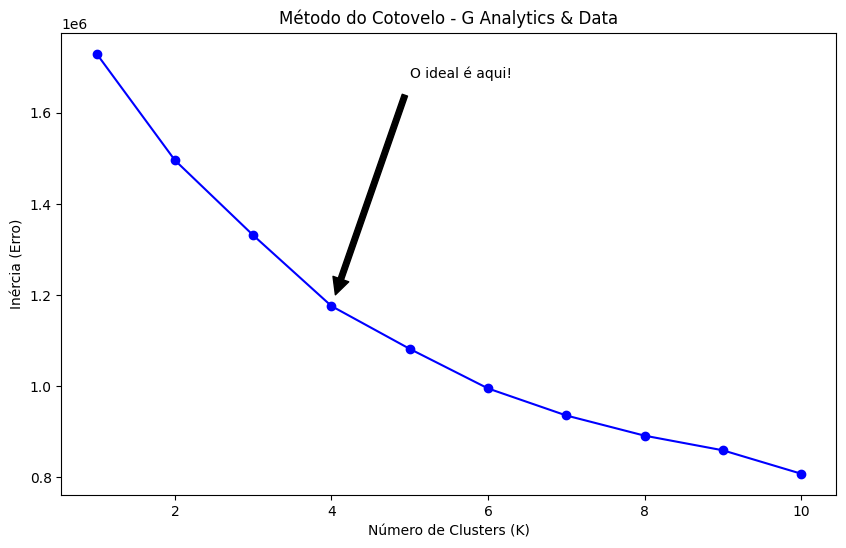

In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Calculando o erro (inércia) para diferentes quantidades de grupos
inercia = []
K = range(1, 11) # Vamos testar de 1 a 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inercia.append(kmeans.inertia_)

# 2. Criando o gráfico
plt.figure(figsize=(10, 6))
plt.plot(K, inercia, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (Erro)')
plt.title('Método do Cotovelo - G Analytics & Data')
plt.annotate('O ideal é aqui!', xy=(4, inercia[3]), xytext=(5, inercia[3]+500000),
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.show()

Etapa 8: Criação dos Segmentos (Clusterização Final)

Nesta etapa, aplicamos o algoritmo K-Means com o parâmetro $K=4$, conforme definido pelo Método do Cotovelo. O algoritmo realiza as seguintes ações:Agrupamento: Calcula a proximidade entre os clientes com base em todas as 18 variáveis comportamentais.Rotulagem: Atribui cada cliente a um grupo específico (0, 1, 2 ou 3).Consolidação: Salva essa classificação no nosso DataFrame principal (df_clean), permitindo que agora possamos analisar o perfil médio de cada segmento.

In [11]:
# 1. Aplicando o modelo com o K=4 que identificamos
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_clean['cluster'] = kmeans_final.fit_predict(df_scaled)

# 2. Conferindo o resultado
print("Quantidade de clientes em cada grupo:")
print(df_clean['cluster'].value_counts())

Quantidade de clientes em cada grupo:
cluster
0    69944
1    19703
3     3283
2     3166
Name: count, dtype: int64


Etapa 9: Caracterização dos Segmentos (Profiling)

Agora que o algoritmo já agrupou os clientes por semelhança, precisamos descobrir quem é quem.
Nesta etapa, calculamos a média dos valores reais para cada coluna dentro de cada cluster. Isso nos permite identificar padrões, como:

Qual grupo traz o maior faturamento (VIPs).

Qual grupo tem os maiores atrasos na entrega (Críticos).

Qual grupo é composto por compradores ocasionais de baixo ticket (Econômicos).

Ao final desta análise, transformaremos os números (0, 1, 2, 3) em nomes estratégicos que guiarão as decisões da empresa.

In [12]:
# 1. Calculando a média de cada coluna por cluster
# Usamos o df_clean porque queremos ver os valores REAIS (Reais, Dias, Notas), não os escalonados.
perfil_clusters = df_clean.groupby('cluster')[colunas_cluster].mean()

# 2. Adicionando a quantidade de clientes em cada grupo para contexto
perfil_clusters['qtd_clientes'] = df_clean['cluster'].value_counts()

# 3. Transpondo (girando) a tabela para facilitar a comparação entre os grupos
tabela_perfil = perfil_clusters.T.round(2)

tabela_perfil

cluster,0,1,2,3
qtd_registros_compras,1.00,1.01,1.01,1.95
qtd_entregue,0.97,0.98,0.97,2.05
media_dias_entrega,11.81,12.85,14.59,11.42
media_dias_atrasoso,-10.76,-9.83,-10.38,-12.44
valor_total_pago,133.27,121.92,1049.77,293.02
media_parcelas,3.24,1.00,6.54,3.56
pag_credito,0.98,0.00,0.88,1.57
pag_boleto,0.00,0.93,0.13,0.31
pag_voucher,0.07,0.00,0.04,0.17
pag_debito,0.00,0.07,0.01,0.02


Etapa 10: Atribuição de Nomes Estratégicos e Volumetria

Nesta etapa, transformamos os números da IA em categorias de negócio e contamos quantos clientes temos em cada "balde".

In [19]:
# 1. Definindo o dicionário com nomes voltados para insights
mapeamento_estrategico = {
    0: 'Potenciais (Base Comum)',
    1: 'Econômicos (Foco Boleto)',
    2: 'Diamante (High Value)',
    3: 'Engajados (Recorrentes)'
}

# 2. Aplicando o mapeamento e resetando o índice
df_resultado = df_clean.copy().reset_index()
df_resultado['segmento_nome'] = df_resultado['cluster'].map(mapeamento_estrategico)

# 3. Criando o resumo: Segmento, Cluster e Quantidade
resumo_volumetria = df_resultado.groupby(['segmento_nome', 'cluster']).size().reset_index(name='qtd_clientes')
resumo_volumetria = resumo_volumetria.sort_values(by='qtd_clientes', ascending=False)

# 4. Formatando os números com separador de milhar (ponto)
# Isso deixa o 69944 como 69.944 para facilitar a leitura
resumo_formatado = resumo_volumetria.style.format({
    'qtd_clientes': '{:,.0f}'.format
}).hide(axis='index') # Esconde aquela coluna de números 0, 1, 2 da lateral

# Exibindo o resultado final elegante
print("Resumo de Segmentação - G Analytics & Data")
display(resumo_formatado)

Resumo de Segmentação - G Analytics & Data


segmento_nome,cluster,qtd_clientes
Potenciais (Base Comum),0,"69,944"
Econômicos (Foco Boleto),1,"19,703"
Engajados (Recorrentes),3,"3,283"
Diamante (High Value),2,"3,166"


Etapa 11: Consolidação do Analítico por Cliente**

Nesta etapa, geramos a lista nominal que vincula cada **ID Único do Cliente** ao seu respectivo **Segmento Estratégico**. 

Este "carimbo" individual é o que permite a personalização:
* **Identificação:** Sabemos exatamente quem pertence a qual grupo.
* **Ação:** Base pronta para ser utilizada em ferramentas de CRM e automação de marketing.
* **Auditabilidade:** Permite conferir linha a linha se a classificação da IA faz sentido com o histórico do cliente.

In [21]:
# 1. Pegamos o resultado e garantimos que o ID vire uma coluna chamada 'cliente'
lista_final_clusters = df_resultado.reset_index().rename(columns={'id_unico_cliente': 'cliente'})

# 2. Selecionamos apenas as duas colunas que você quer ver
lista_final_clusters = lista_final_clusters[['cliente', 'segmento_nome']]

# 3. Verificamos o total de linhas para garantir que os 96.096 estão aí
print(f"Total de clientes na lista: {len(lista_final_clusters):,}".replace(",", "."))

# 4. Exibimos a lista
display(lista_final_clusters)

Total de clientes na lista: 96.096


,cliente,segmento_nome
0,0000366f3b9a7992bf8c76cfdf3221e2,Potenciais (Base Comum)
1,0000b849f77a49e4a4ce2b2a4ca5be3f,Potenciais (Base Comum)
2,0000f46a3911fa3c0805444483337064,Potenciais (Base Comum)
3,0000f6ccb0745a6a4b88665a16c9f078,Potenciais (Base Comum)
4,0004aac84e0df4da2b147fca70cf8255,Potenciais (Base Comum)
...,...,...
96091,fffcf5a5ff07b0908bd4e2dbc735a684,Diamante (High Value)
96092,fffea47cd6d3cc0a88bd621562a9d061,Potenciais (Base Comum)
96093,ffff371b4d645b6ecea244b27531430a,Potenciais (Base Comum)
96094,ffff5962728ec6157033ef9805bacc48,Potenciais (Base Comum)


Etapa 12: Persistência de Dados - Integração com o Data Warehouse

Para encerrar o ciclo de dados, exportamos a tabela final diretamente para o nosso banco de dados SQL. 

Ao criar a tabela `TB_CLIENTES_SEGMENTADOS`, garantimos que a inteligência gerada no Python não fique isolada, tornando-se acessível para:
1. **Consultas SQL:** Cruzamentos complexos com tabelas de logística, produtos e faturamento.
2. **Escalabilidade:** Os dados agora estão protegidos e estruturados no ambiente de produção da **G Analytics & Data**.

In [23]:
# 1. Definindo o nome e o local exato
nome_tabela_destino = 'tb_dim_customers_segmented'
schema_destino = 'analytics'

# 2. Gravando especificando o schema
lista_final_clusters.to_sql(
    nome_tabela_destino, 
    con=engine, 
    index=False, 
    if_exists='replace',
    schema=schema_destino  # <--- Isso garante que vá para o lugar certo
)

print(f"Sucesso! A tabela '{schema_destino}.{nome_tabela_destino}' foi criada com sucesso.")

Sucesso! A tabela 'analytics.tb_dim_customers_segmented' foi criada com sucesso.
